# TT-04 — Logistic Regression: Chẩn đoán nguy cơ bệnh tim

Dữ liệu: Heart Disease (UCI Cleveland / bản Kaggle).
Đặt file CSV tải về tại `data/heart.csv` trước khi chạy notebook này.

- UCI: https://archive.ics.uci.edu/dataset/45/heart+disease
- Kaggle: https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.dummy import DummyClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, precision_recall_curve,
                              recall_score, precision_score, classification_report)

RANDOM_STATE = 42


## 1. Đọc dữ liệu và loại dòng trùng lặp

Bản Kaggle (1.025 dòng) là bản nhân bản từ 303 dòng gốc → phải `drop_duplicates()` trước khi chia train/test, nếu không sẽ rò rỉ dữ liệu.

In [2]:
df_raw = pd.read_csv('heart.csv')
n_before = len(df_raw)

df = df_raw.drop_duplicates().reset_index(drop=True)
n_after = len(df)

print(f"Số dòng trước khi loại trùng: {n_before}")
print(f"Số dòng sau khi loại trùng:  {n_after}")
print(f"Đã loại bỏ: {n_before - n_after} dòng trùng lặp")

df.head()

Số dòng trước khi loại trùng: 1025
Số dòng sau khi loại trùng:  302
Đã loại bỏ: 723 dòng trùng lặp


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## 2. Xác định biến phân loại

`cp`, `restecg`, `slope`, `thal`, `ca` là các mã số phân loại, không có thứ tự thật sự → cần one-hot encode, không được để nguyên dạng số.

In [3]:
target_col = 'target'  #gán tên cột mục tiêu

categorical_cols = ['cp', 'restecg', 'slope', 'thal', 'ca', 'sex', 'fbs', 'exang']  #khai báo ds các cột chưa biến phân loại 
numeric_cols = [c for c in df.columns if c not in categorical_cols + [target_col]]

print("Biến phân loại:", categorical_cols)
print("Biến số:", numeric_cols)

for col in ['ca', 'thal']:   #duyệt qua hai cột 'ca' và 'thal' để in ra số lượng giá trị duy nhất trong mỗi cột
    print(f"\n{col}:\n{df[col].value_counts()}")

Biến phân loại: ['cp', 'restecg', 'slope', 'thal', 'ca', 'sex', 'fbs', 'exang']
Biến số: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

ca:
ca
0    175
1     65
2     38
3     20
4      4
Name: count, dtype: int64

thal:
thal
2    165
3    117
1     18
0      2
Name: count, dtype: int64


## 3. EDA nhanh

In [4]:
import os
os.makedirs('reports', exist_ok=True)  #tạo thư mục
os.makedirs('models', exist_ok=True)

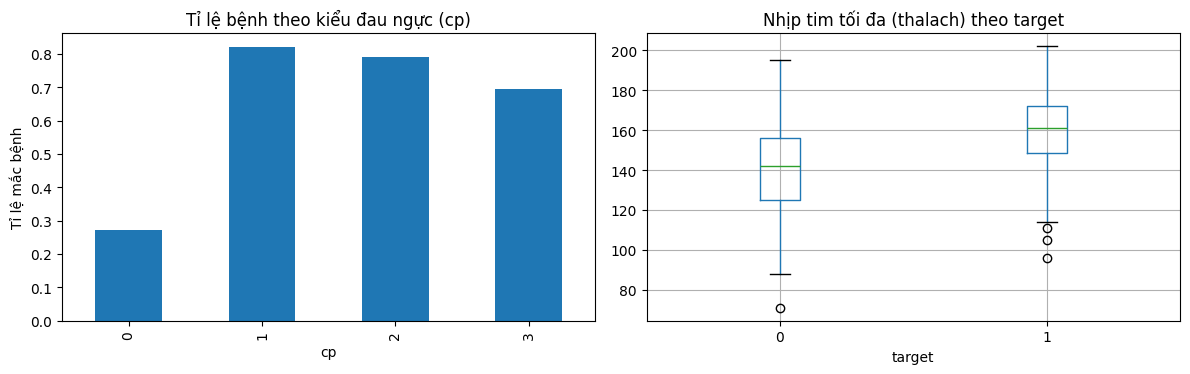

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df.groupby('cp')[target_col].mean().plot(kind='bar', ax=axes[0], title='Tỉ lệ bệnh theo kiểu đau ngực (cp)')
axes[0].set_ylabel('Tỉ lệ mắc bệnh')

df.boxplot(column='thalach', by=target_col, ax=axes[1])
axes[1].set_title('Nhịp tim tối đa (thalach) theo target')      #đặt tên cho biểu đồ
plt.suptitle('')
plt.tight_layout()
plt.savefig('reports/eda.png', dpi=120)
plt.show()

## 4. Chia train/test và xây Pipeline

Pipeline: OneHotEncoder cho biến phân loại + StandardScaler cho biến số, sau đó LogisticRegression.

In [6]:
X = df.drop(columns=[target_col])  #Dòng này tạo ra biến X chứa tất cả các cột thông tin, ngoại trừ cột mục tiêu (target_col)
y = df[target_col]  #Dòng này tạo ra biến y chỉ chứa duy nhất cột mục tiêu 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,
          stratify=y, #đảm bảo tỉ lệ người bệnh và khỏe ở cả 2 tập giống nhau
          random_state=RANDOM_STATE)  #giúp cố định cách chia dữ liệu, để mỗi lần chạy sẽ cho ra kết quả giống nhau

preprocess = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first'), categorical_cols),
    ('num', StandardScaler(), numeric_cols),
])

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (241, 13), Test: (61, 13)


## 5. Baseline (DummyClassifier)

In [7]:
baseline = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
baseline.fit(X_train, y_train)
print(classification_report(y_test, baseline.predict(X_test)))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        28
           1       0.54      1.00      0.70        33

    accuracy                           0.54        61
   macro avg       0.27      0.50      0.35        61
weighted avg       0.29      0.54      0.38        61



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## 6. Huấn luyện Logistic Regression và bảng Odds Ratio

**Lưu ý quan trọng:** dùng `scoring='roc_auc'` cho `LogisticRegressionCV`, **không** dùng `scoring='recall'`.

Nếu tối ưu trực tiếp recall, CV có xu hướng chọn `C` rất nhỏ (phạt mạnh) vì cách đơn giản nhất
để đạt recall cao là mô hình gần như luôn dự đoán lớp dương — hệ số co gần về 0, bảng odds ratio
trở nên vô nghĩa (mọi OR ≈ 1, |w| < 0.01). `roc_auc` đo khả năng phân biệt tổng thể của mô hình
trên mọi ngưỡng, không khuyến khích hành vi suy biến này. Ngưỡng phân loại theo recall mong muốn
sẽ được chọn riêng ở bước 9, dựa trên out-of-fold prediction trên tập train.


In [8]:
logreg_pipeline = Pipeline([
    ('preprocess', preprocess),
    ('model', LogisticRegressionCV(Cs=10, cv=5, penalty='l2',
                                    scoring='roc_auc', max_iter=2000,
                                    random_state=RANDOM_STATE)),
])
logreg_pipeline.fit(X_train, y_train)

feature_names = logreg_pipeline.named_steps['preprocess'].get_feature_names_out()
coefs = logreg_pipeline.named_steps['model'].coef_[0]

odds_ratio = pd.DataFrame({
    'dac_trung': feature_names,
    'he_so_w': coefs,
    'odds_ratio': np.exp(coefs),
}).sort_values('odds_ratio', ascending=False)

# Sanity check: phát hiện sớm nếu mô hình bị co hệ số về 0 (dấu hiệu CV chọn C quá nhỏ)
max_abs_w = np.abs(coefs).max()
if max_abs_w < 0.05:
    print(f"CẢNH BÁO: |hệ số| lớn nhất chỉ {max_abs_w:.4f} -> mô hình có thể bị co hệ số về 0, "
          "kiểm tra lại scoring của LogisticRegressionCV.")
else:
    print(f"OK: |hệ số| lớn nhất = {max_abs_w:.4f}, C được chọn = {logreg_pipeline.named_steps['model'].C_[0]:.4g}")

odds_ratio.to_csv('reports/odds_ratio.csv', index=False)
odds_ratio


OK: |hệ số| lớn nhất = 1.2121, C được chọn = 0.3594


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or 

,dac_trung,he_so_w,odds_ratio
1,cat__cp_2,1.070801,2.917717
2,cat__cp_3,0.837994,2.311725
20,num__thalach,0.651009,1.917475
8,cat__thal_2,0.563871,1.757463
0,cat__cp_1,0.414614,1.513787
3,cat__restecg_1,0.324547,1.383404
6,cat__slope_2,0.219258,1.245153
7,cat__thal_1,0.199475,1.220762
13,cat__ca_4,0.159128,1.172488
17,num__age,0.104537,1.110196


## 7. So sánh L1 (Lasso) và L2 (Ridge)

`C = 1/λ` → C nhỏ nghĩa là phạt mạnh (ngược trực giác). Cũng dùng `scoring='roc_auc'` như ở bước
trước để tránh lỗi mô hình co hệ số về 0 (ở bản trước, dùng `scoring='recall'` khiến L1 "chết":
AUC = 0.500 và toàn bộ 22 hệ số = 0).


In [9]:
def fit_and_score(penalty, solver):
    pipe = Pipeline([
        ('preprocess', preprocess),
        ('model', LogisticRegressionCV(Cs=10, cv=5, penalty=penalty, solver=solver,
                                        scoring='roc_auc', max_iter=2000,
                                        random_state=RANDOM_STATE)),
    ])
    pipe.fit(X_train, y_train)
    auc = roc_auc_score(y_test, pipe.predict_proba(X_test)[:, 1])
    n_zero = np.sum(np.isclose(pipe.named_steps['model'].coef_[0], 0))
    return pipe, auc, n_zero

pipe_l2, auc_l2, zero_l2 = fit_and_score('l2', 'lbfgs')
pipe_l1, auc_l1, zero_l1 = fit_and_score('l1', 'saga')

print(f"L2 (Ridge): AUC = {auc_l2:.3f}, số hệ số = 0: {zero_l2}")
print(f"L1 (Lasso): AUC = {auc_l1:.3f}, số hệ số = 0: {zero_l1}")

for name, auc in [('L2', auc_l2), ('L1', auc_l1)]:
    if auc < 0.6:
        print(f"CẢNH BÁO: AUC của {name} quá thấp ({auc:.3f}) -> mô hình có thể đã 'chết' "
              "(kiểm tra scoring / C được chọn).")


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or 

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or 

L2 (Ridge): AUC = 0.906, số hệ số = 0: 0
L1 (Lasso): AUC = 0.902, số hệ số = 0: 2


## 8. Đường ROC và Precision-Recall

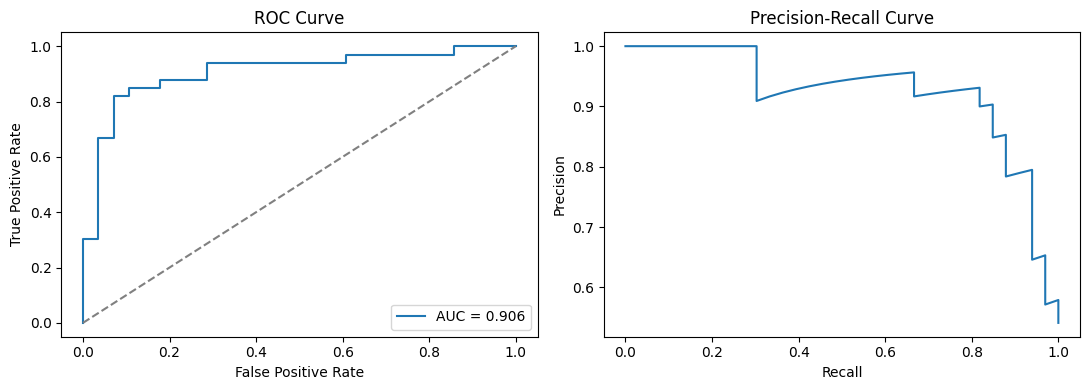

In [10]:
y_proba = logreg_pipeline.predict_proba(X_test)[:, 1]

fpr, tpr, roc_thr = roc_curve(y_test, y_proba)
precision, recall, pr_thr = precision_recall_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(fpr, tpr, label=f'AUC = {auc:.3f}')
axes[0].plot([0, 1], [0, 1], '--', color='gray')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve'); axes[0].legend()

axes[1].plot(recall, precision)
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')

plt.tight_layout()
plt.savefig('reports/roc_pr_curve.png', dpi=120)
plt.show()

## 9. Chọn ngưỡng đạt recall ≥ 0,90

Ngưỡng được chọn bằng **out-of-fold prediction trên tập train** (`cross_val_predict`, 5-fold),
sau đó áp dụng cố định lên tập test để báo cáo precision/recall.

Không dò ngưỡng trực tiếp trên `precision_recall_curve` của tập test — nếu làm vậy, ngưỡng được
"fit" bằng chính dữ liệu dùng để báo cáo hiệu năng cuối cùng, khiến precision/recall trên test
lạc quan hơn thực tế (một dạng rò rỉ dữ liệu qua việc chọn siêu tham số).


In [11]:
target_recall = 0.90

# Ngưỡng được chọn bằng out-of-fold probability trên TẬP TRAIN (không đụng tới tập test).
oof_proba = cross_val_predict(logreg_pipeline, X_train, y_train, cv=5, method='predict_proba')[:, 1]
prec_oof, rec_oof, thr_oof = precision_recall_curve(y_train, oof_proba)

valid_oof = rec_oof[:-1] >= target_recall
best_idx_oof = np.where(valid_oof)[0][-1]  # ngưỡng cao nhất vẫn đạt recall mong muốn
chosen_threshold = thr_oof[best_idx_oof]

print(f"Ngưỡng chọn (out-of-fold, TRAIN): {chosen_threshold:.3f}")
print(f"Recall (out-of-fold, TRAIN):    {rec_oof[best_idx_oof]:.3f}")
print(f"Precision (out-of-fold, TRAIN): {prec_oof[best_idx_oof]:.3f}")

# Áp dụng ngưỡng cố định (đã chọn xong) lên tập TEST - chỉ đánh giá, không dò lại
y_pred_thr = (y_proba >= chosen_threshold).astype(int)
print("\nKết quả trên tập TEST với ngưỡng cố định ở trên:")
print(classification_report(y_test, y_pred_thr))


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or 

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or 

Ngưỡng chọn (out-of-fold, TRAIN): 0.430
Recall (out-of-fold, TRAIN):    0.901
Precision (out-of-fold, TRAIN): 0.797

Kết quả trên tập TEST với ngưỡng cố định ở trên:
              precision    recall  f1-score   support

           0       0.85      0.82      0.84        28
           1       0.85      0.88      0.87        33

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or 

## 10. Kiểm tra đa cộng tuyến (VIF)

Chỉ tính VIF trên các biến số (đã chuẩn hoá) của **tập train** — không dùng toàn bộ `df`
(train + test) như bản trước, để tránh thông tin từ tập test rò rỉ vào bước phân tích mô hình.


In [12]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_num_train = StandardScaler().fit_transform(X_train[numeric_cols])
vif = pd.DataFrame({
    'bien': numeric_cols,
    'VIF': [variance_inflation_factor(X_num_train, i) for i in range(len(numeric_cols))]
}).sort_values('VIF', ascending=False)

vif.to_csv('reports/vif_table.csv', index=False)
print(vif)
print("\nBiến có VIF > 10 (đáng lo ngại):", list(vif.loc[vif['VIF'] > 10, 'bien']))


       bien       VIF
3   thalach  1.307942
0       age  1.290903
4   oldpeak  1.199534
1  trestbps  1.113208
2      chol  1.076433

Biến có VIF > 10 (đáng lo ngại): []


## 11. So sánh với SVM và Random Forest

In [13]:
models = {
    'LogisticRegression': logreg_pipeline,
    'SVM': Pipeline([('preprocess', preprocess),
                      ('model', SVC(probability=True, random_state=RANDOM_STATE))]),
    'RandomForest': Pipeline([('preprocess', preprocess),
                               ('model', RandomForestClassifier(random_state=RANDOM_STATE))]),
}

results = []
for name, model in models.items():
    if name != 'LogisticRegression':
        model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    results.append({
        'model': name,
        'roc_auc': roc_auc_score(y_test, proba),
        'recall_at_0.5': recall_score(y_test, (proba >= 0.5).astype(int)),
        'precision_at_0.5': precision_score(y_test, (proba >= 0.5).astype(int)),
    })

pd.DataFrame(results)

,model,roc_auc,recall_at_0.5,precision_at_0.5
0,LogisticRegression,0.905844,0.848485,0.848485
1,SVM,0.877706,0.757576,0.862069
2,RandomForest,0.887446,0.787879,0.812500


## 12. Giải thích cho một bệnh nhân cụ thể

In [14]:
patient = X_test.iloc[[0]]
patient_proba = logreg_pipeline.predict_proba(patient)[0, 1]

print(f"Xác suất mô hình dự đoán nguy cơ bệnh tim: {patient_proba:.1%}")
print(f"Nhãn thực tế: {'Có bệnh' if y_test.iloc[0] == 1 else 'Không bệnh'}")
print()
print("3 yếu tố nguy cơ có odds ratio cao nhất trong mô hình:")
print(odds_ratio.head(3)[['dac_trung', 'odds_ratio']])
print()
print("Diễn giải mẫu: 'Dựa trên các chỉ số đo được (đau ngực kiểu ..., "
      "nhịp tim tối đa ..., ...), mô hình ước tính xác suất mắc bệnh tim là "
      f"{patient_proba:.0%}. Đây là công cụ hỗ trợ tham khảo, quyết định "
      "chẩn đoán cuối cùng vẫn thuộc về bác sĩ.'")

Xác suất mô hình dự đoán nguy cơ bệnh tim: 20.8%
Nhãn thực tế: Không bệnh

3 yếu tố nguy cơ có odds ratio cao nhất trong mô hình:
       dac_trung  odds_ratio
1      cat__cp_2    2.917717
2      cat__cp_3    2.311725
20  num__thalach    1.917475

Diễn giải mẫu: 'Dựa trên các chỉ số đo được (đau ngực kiểu ..., nhịp tim tối đa ..., ...), mô hình ước tính xác suất mắc bệnh tim là 21%. Đây là công cụ hỗ trợ tham khảo, quyết định chẩn đoán cuối cùng vẫn thuộc về bác sĩ.'


## 13. Giới hạn mô hình và lưu ý đạo đức

- Đây là **công cụ hỗ trợ tham khảo**, không phải công cụ chẩn đoán — quyết định lâm sàng cuối
  cùng luôn thuộc về bác sĩ.
- Dữ liệu huấn luyện có quy mô nhỏ (vài trăm dòng sau khi loại trùng) và thu thập từ một số
  bệnh viện nhất định → mô hình có thể không tổng quát tốt cho các quần thể bệnh nhân khác
  (khác độ tuổi, chủng tộc, khu vực địa lý...). Chưa có bước kiểm tra thiên lệch (bias) theo
  nhóm nhân khẩu học (ví dụ theo giới tính `sex`).
- Ngưỡng được chọn để đạt recall ≥ 0.90 nghĩa là ưu tiên không bỏ sót bệnh nhân có bệnh, đổi lại
  chấp nhận nhiều cảnh báo giả (precision thấp hơn) — cần nêu rõ đánh đổi này khi trình bày kết
  quả cho người không chuyên.
- Trước khi dùng trong thực tế cần được kiểm định lâm sàng (external validation) trên dữ liệu
  độc lập, không chỉ đánh giá nội bộ trên một lần chia train/test.
